In [997]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import numpy as np
import random

from tqdm import tqdm
from IPython.display import clear_output

device = 'cuda' if torch.cuda.is_available() else 'cpu'
# device = 'cpu'
device

'cuda'

In [998]:
TRAJECTORY_LEN = 1001
STATE_DIM = 29
# FEATURES_TO_CONSIDER = [0, 1, 15, 16]
FEATURES_TO_CONSIDER = torch.arange(29)

KEEP_ONLY_COORDS = False

In [999]:
def reset_to_location(env, location):
    env.sim.reset()
    qpos = env.init_qpos + env.np_random.uniform(low=-.1, high=.1, size=env.model.nq)
    qpos[:2] = np.array(location).astype(env.observation_space.dtype)
    qvel = env.init_qvel + env.np_random.randn(env.model.nv) * .1
    env.set_state(qpos, qvel)
    return env.unwrapped._get_obs()

In [1000]:
import gym
import d4rl # Import required to register environments, you may need to also import the submodule

# Create the environment
env = gym.make('antmaze-large-diverse-v2')
dataset = env.get_dataset()

/home/nazim/.local/lib/python3.10/site-packages/gym/spaces/box.py:84: UserWarning: WARN: Box bound precision lowered by casting to float32
  logger.warn(f"Box bound precision lowered by casting to {self.dtype}")


Target Goal:  (32.56541036052551, 24.913591095407025)


load datafile: 100%|██████████| 8/8 [00:01<00:00,  5.59it/s]


In [1001]:
dataset_trajectories = torch.tensor(dataset['observations'])
dataset_trajectories = dataset_trajectories[..., :STATE_DIM]
# dataset_trajectories = torch.concatenate((dataset_trajectories[..., [0, 1]], dataset_trajectories[..., [15, 16]]), dim=-1)

dataset_actions = torch.tensor(dataset['actions'])
dataset_terminals = torch.tensor(dataset['terminals'])
dataset_timeouts = torch.tensor(dataset['timeouts'])

dataset_goals = torch.tensor(dataset['infos/goal'])



# [:999*1001]

dataset_trajectories = dataset_trajectories[:999*1001].reshape(-1, 1001, STATE_DIM)
dataset_actions = dataset_actions[:999*1001].reshape(-1, 1001, 8)
dataset_terminals = dataset_terminals[:999*1001]
dataset_timeouts = dataset_timeouts[:999*1001].reshape(-1, 1001)


num_trajectories, len_trajectory, obs_dim = dataset_trajectories.shape

In [1002]:
dataset_mean = dataset_trajectories.mean([0, 1])
dataset_std = dataset_trajectories.std([0, 1])
dataset_std = torch.ones_like(dataset_std)

def normalize_dataset_coords(dataset_, features_to_consider_only=False):
    # return dataset_    
    is_numpy = isinstance(dataset_, np.ndarray)
    if is_numpy: dataset_ = torch.tensor(dataset_)
    
    dataset = dataset_.clone()
    if not features_to_consider_only:
        dataset = (dataset - dataset_mean.to(dataset.device)) / dataset_std.to(dataset.device)
    else:
        dataset = (dataset - dataset_mean[FEATURES_TO_CONSIDER]) / dataset_std[FEATURES_TO_CONSIDER]
    if is_numpy: dataset = np.array(dataset.cpu())
    return dataset

# def denormalize_dataset_coords(dataset_, features_to_consider_only=False):
#     # return dataset_
#     is_numpy = isinstance(dataset_, np.ndarray)
#     if is_numpy: dataset_ = torch.tensor(dataset_)
#     dataset = dataset_.clone()
#     if not features_to_consider_only:
#         dataset = dataset * dataset_std + dataset_mean
#     else:
#         dataset = dataset * dataset_std[FEATURES_TO_CONSIDER] + dataset_mean[FEATURES_TO_CONSIDER]
#     if is_numpy: dataset = np.array(dataset.cpu())
#     return dataset

# dataset_trajectories = normalize_dataset_coords(dataset_trajectories)
dataset_trajectories_cuda = dataset_trajectories.to(device)


In [1003]:
import torch
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a long enough PEs tensor
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # (1, max_len, d_model) so it can be broadcast over batch
        pe = pe.unsqueeze(0)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x: (batch_size, seq_len, d_model)
        x = x + self.pe[:, :x.size(1), :]  # match seq_len
        return self.dropout(x)


In [1004]:
class FRENetwork(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=128):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)
        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
        )


    def get_transformer_encoding(self, reward_state_pairs):
        reward_states = reward_state_pairs[:, :, :-1]
        reward_values = reward_state_pairs[:, :, -1]
        reward_values_idx = torch.floor((reward_values / 2.0 + 0.5) * self.num_discrete_embeddings).int()
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        reward_state_emb = self.state_embed(reward_states)
        reward_state_val = self.reward_embed(reward_values_idx)
        
        reward_state_pairs = torch.concatenate([reward_state_emb, reward_state_val], axis=-1)

        w_pre = self.encoder_transformer(reward_state_pairs) # [batch, reward_pairs, emb_dim]
        
        w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]
        

# Reward Generator:

In [1005]:
EPISODE_LENGTH = TRAJECTORY_LEN
Z_DIM = 128
MIN_NUM_ANCHORS = 8
MAX_NUM_ANCHORS = 16

In [1006]:
from utils.reward_alignement import RNDModule, RNDResampling

In [1007]:
class RewardGeneratorTransformer(nn.Module):
    def __init__(self, obs_len, num_heads=2, num_layers=2, reward_pairs_emb_dim=Z_DIM):
        super().__init__()
        
        self.obs_len = obs_len
        self.reward_pairs_emb_dim = reward_pairs_emb_dim
        self.num_discrete_embeddings = 32
        
        self.encoder_transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                self.reward_pairs_emb_dim, 
                num_heads, 
                dim_feedforward=4*self.reward_pairs_emb_dim, 
                batch_first=True
            ),
            num_layers=num_layers
        )
        self.encoder_mean = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)
        self.encoder_log_std = nn.Linear(self.reward_pairs_emb_dim, self.reward_pairs_emb_dim)

        self.state_embed = nn.Linear(self.obs_len, self.reward_pairs_emb_dim // 2)
        self.reward_embed = nn.Embedding(self.num_discrete_embeddings, self.reward_pairs_emb_dim // 2)

        self.reward_predict = nn.Sequential(
            nn.Linear(self.obs_len + self.reward_pairs_emb_dim, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 512),
            nn.LayerNorm(512),
            nn.Mish(),
            nn.Linear(512, 1),
            nn.Tanh()
        )



    def get_transformer_encoding(self, states, rewards, pad_mask):  
        
        mask = (states != 0).float()
        states = normalize_dataset_coords(states)
        states = states * mask
        
        batch_size, num_anchors = states.shape[0], states.shape[1]
        
        if pad_mask is None:
            pad_mask = torch.zeros((batch_size, num_anchors), dtype=torch.bool, device=device)
        # pad_mask.shape = [batch, anchors]
        
        # reward_values_idx = torch.floor(rewards * self.num_discrete_embeddings).int()
        reward_values_idx = torch.floor((rewards*0.5+0.5) * self.num_discrete_embeddings).int() # dont forget that rewards are in [-1, 1]
        reward_values_idx = torch.clip(reward_values_idx, 0, self.num_discrete_embeddings - 1)

        
        state_emb = self.state_embed(states)
        reward_emb = self.reward_embed(reward_values_idx.squeeze(-1))
        state_reward_emd = torch.concat((state_emb, reward_emb), dim=-1)
        
        w_pre = self.encoder_transformer(state_reward_emd, src_key_padding_mask=pad_mask) # [batch, anchors, emb_dim]
        
        
        valid_tokens = (~pad_mask).float()  # (B, T), converts True -> 0, False -> 1
        valid_tokens = valid_tokens.unsqueeze(-1)  # (B, T, 1)
        sum_embeddings = (w_pre * valid_tokens).sum(dim=1)  # Sum over sequence dimension
        w_pair_mean = sum_embeddings / valid_tokens.sum(dim=1)
        
        # w_pair_mean = w_pre.mean(axis=1)
        # print(w_pair_mean.shape)
        w_mean = self.encoder_mean(w_pair_mean)
        w_log_std = self.encoder_log_std(w_pair_mean)

        return w_mean, w_log_std # (batch_size, emb_dim)
    
    
    def get_reward_pred(self, w, reward_states): # Reward Pairs: [batch, reward_pairs, obs_dim + 1]
                        
        mask = (reward_states != 0).float()
        reward_states = normalize_dataset_coords(reward_states)
        reward_states = reward_states * mask
        
        z_expand = w.unsqueeze(1) # [batch, 1, emb_dim]
        z_expand = z_expand.repeat(1, reward_states.shape[1], 1)        
        
        w_and_obs = torch.concatenate([z_expand, reward_states], axis=-1)
        
        reward_pred = self.reward_predict(w_and_obs)
        
        return reward_pred # [batch, reward_pairs]

In [1009]:
class RewardGenerator:
    def __init__(self, fre_network: RewardGeneratorTransformer):
        
        self.fre_network = fre_network.to(device)
        self.optimimizer = torch.optim.Adam(self.fre_network.parameters(), lr=0.001)
        
        self.len_params = Z_DIM
        self.resampling_weights = None
        
    
    def get_reward(self, obs, w):
        self.fre_network.eval()
        
        # obs.shape == (batch_size, obs_len)
        # w.shape == (batch_size, w_dim)
        assert obs.shape[0] == w.shape[0]
        assert len(obs.shape) == 2
        
        obs = obs.unsqueeze(1)
        with torch.no_grad():
            rewards_pred = self.fre_network.get_reward_pred(w, obs)
        
        return rewards_pred.reshape(-1, 1)
    
    
    def get_training_data(self, batch_size, min_num_anchors, max_num_anchors):
        assert min_num_anchors <= max_num_anchors

        obs_dim = dataset_trajectories.shape[-1]
        

        # buffer = dataset_trajectories[..., :2].reshape(-1, 2)
        buffer = dataset_trajectories[..., :].reshape(-1, obs_dim)
        
        anchors = torch.zeros((batch_size, max_num_anchors, obs_dim), dtype=torch.float32)

        idx = self.get_importance_sampling_indices(batch_size*max_num_anchors,)
        # anchors = buffer[idx, :2]
        anchors = buffer[idx, :]
        anchors = anchors.reshape(batch_size, max_num_anchors, obs_dim)

            
        anchors_rewards = torch.zeros((batch_size, max_num_anchors), dtype=torch.float32)
        pad_mask = torch.ones((batch_size, max_num_anchors), dtype=torch.bool)

        # Generate random number of anchors for each batch element
        num_anchors = torch.randint(min_num_anchors, max_num_anchors + 1, (batch_size,))

        reward_indices = torch.arange(max_num_anchors).unsqueeze(0)
        reward_mask = reward_indices < num_anchors.unsqueeze(1)

        
        # candidates = torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.])
        
        reward_types = torch.ones((batch_size,), dtype=torch.long) # 0: goal reaching | 1: MLP
        
        candidates = [
            torch.tensor([-1, -0.75, -0.5, -0.25, 0.0, 0.25, 0.5, 0.75, 1.]),
            torch.tensor([-1, -0.75, -0.5, -0.25, 0.0]),
            torch.tensor([0.0, 0.25, 0.5, 0.75, 1.]),
        ]
        res = []
        for b in range(batch_size):
            x = torch.randint(0, len(candidates), (1,))
            res.append(candidates[x][torch.randint(0, candidates[x].shape[0], (max_num_anchors,))])
        anchors_rewards = torch.stack(res)
        
        # anchors_rewards[reward_mask] = candidates[torch.randint(0, candidates.shape[0], (reward_mask.sum(),))]
        
        # Goal reaching reward functions:
        random_rows = torch.tensor([n for n in range(batch_size) if random.random() < 0.3], dtype=torch.long)
        anchors_rewards[random_rows] = -1.
        anchors_rewards[random_rows, 0] = 1.
        reward_types[random_rows] = 0

            
        # rewards[reward_mask] = torch.exp(2*(rewards[reward_mask] - 1))
        anchors_rewards = anchors_rewards.unsqueeze(-1)

        pad_mask_indices = torch.arange(max_num_anchors).unsqueeze(0)
        pad_mask = pad_mask_indices < num_anchors.unsqueeze(1)
        pad_mask = ~pad_mask
                
        
        anchors = anchors[..., FEATURES_TO_CONSIDER].float()
        anchors_rewards = anchors_rewards.float()
        pad_mask = pad_mask
        
        return (anchors, anchors_rewards, pad_mask), {'reward_types':reward_types}
    

    def generate_boolean_mask(self, batch_size, length, p=0.9):
        vecs = (torch.rand(batch_size, length) > p).bool()
        mask = ~vecs.any(dim=1)
        if mask.any():
            rows = mask.nonzero(as_tuple=False).squeeze(1)
            cols = torch.randint(0, length, (rows.size(0),))
            vecs[rows, cols] = True
        
        
        if KEEP_ONLY_COORDS:
            vecs = torch.zeros_like(vecs)
            vecs[:, :2] = True
            
        return vecs * 1.
    
        
    def train_step_VAE(self, batch_size, min_num_anchors, max_num_anchors):
        self.fre_network.train()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.0)
        # mask[..., :2] = 1
        # mask[..., 2:] = 0

        # Only keep coords for goal reaching rewards (reward_types == 0):
        mask[info['reward_types'] == 0, :2] = 1
        mask[info['reward_types'] == 0, 2:] = 0


        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
                

        w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask=pad_mask)
        
        
        
        w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
        # w = w_mean
        rewards_pred = self.fre_network.get_reward_pred(w, anchors)
        
        
        reward_pred_loss = ((rewards_pred[~pad_mask] - anchors_rewards[~pad_mask])**2).mean()
                        
        
        kl_loss = -0.5 * (1 + 2*w_log_std - w_mean**2 - torch.exp(w_log_std)**2).mean()
        loss = reward_pred_loss + kl_loss * 0.01
        
        
        self.optimimizer.zero_grad()
        loss.backward()
        self.optimimizer.step()
        
        return {
            'loss': loss.item(),
            'reward_pred_loss': reward_pred_loss.item(),
            'kl_loss': kl_loss.item(),
            'get_training_data:info': info,
            'anchors': anchors.cpu(),
            'anchors_rewards': anchors_rewards.cpu(),
            'pad_mask': pad_mask.cpu(),
        }
        
    
    def get_z_from_random_anchors(self, batch_size: int, min_num_anchors:int, max_num_anchors:int, mask=None):
        self.fre_network.eval()
        
        (anchors, anchors_rewards, pad_mask), info = self.get_training_data(
            batch_size=batch_size, 
            min_num_anchors=min_num_anchors, 
            max_num_anchors=max_num_anchors,
        )
        anchors = anchors.to(device)
        anchors_rewards = anchors_rewards.to(device)
        pad_mask = pad_mask.to(device)
        
        if mask is None:
            mask = self.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.0)
        
        assert mask.shape == (batch_size, len(FEATURES_TO_CONSIDER))
        
        mask = mask.unsqueeze(1).repeat(1, max_num_anchors, 1)
        mask = mask.to(device)
        anchors = anchors * mask
        
        eval_z, _ = self.get_z_from_anchors(anchors, anchors_rewards, pad_mask)
        
        return eval_z, {
            'anchors': anchors.cpu(), 
            'anchors_rewards': anchors_rewards.cpu(), 
            'pad_mask': pad_mask.cpu(), 
            'get_training_data:info': info
        }
    

    def get_z_from_anchors(self, anchors: torch.Tensor, anchors_rewards: torch.Tensor, pad_mask: torch.Tensor):    
        assert anchors.shape[:-1] == pad_mask.shape
        self.fre_network.eval()
        
        batch_size = anchors.shape[0]
        
        with torch.no_grad():
            w_mean, w_log_std = self.fre_network.get_transformer_encoding(anchors, anchors_rewards, pad_mask) 
        
        # eps = torch.normal(0, 1, (batch_size, self.emperical_mean.shape[0]), device=device)
        # z = w_mean + eps * torch.exp(w_log_std)
        z = w_mean
        
        return z, {'anchors': anchors.cpu()}
            
    
    def get_importance_sampling_indices(self, N):
        indices = torch.multinomial(self.resampling_weights, N, replacement=True)
        return indices

In [1010]:
num_anchors = 16

rg_model = RewardGeneratorTransformer(obs_len=obs_dim)
# rg_model.load_state_dict(torch.load('models/all_in_one-coords-rg_model.pth'))

reward_generator = RewardGenerator(
    fre_network=rg_model,
)

resampler = RNDResampling(state_dim=2)
rnd_dataset = dataset_trajectories[..., :2].reshape(-1, 2)
resampler_losses = resampler.fit(rnd_dataset, epochs=1)
resampling_weights = resampler.get_resampling_weights(rnd_dataset, alpha=0.0)
reward_generator.resampling_weights = resampling_weights


vae_loss, vae_kl_loss = [], []

100%|██████████| 1/1 [00:00<00:00, 451.63it/s]


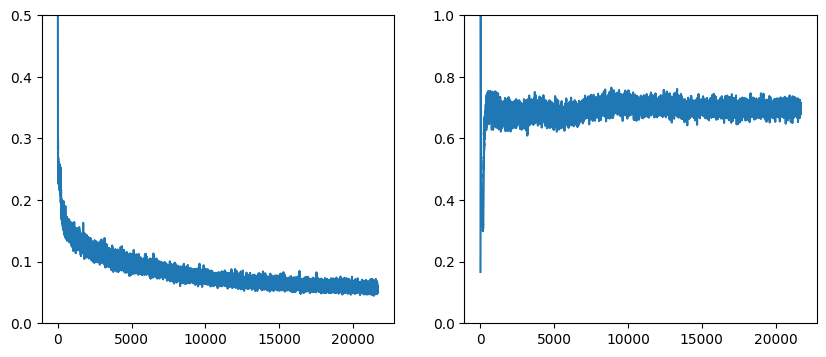

KeyboardInterrupt: 

In [1014]:
print('VAE training...')
for step in tqdm(range(100_000), desc='VAE training', leave=False):
    
    vae_loss_dict = reward_generator.train_step_VAE(
        batch_size=256,
        min_num_anchors=MIN_NUM_ANCHORS,
        max_num_anchors=MAX_NUM_ANCHORS,
    )
    vae_loss.append(vae_loss_dict['loss'])
    vae_kl_loss.append(vae_loss_dict['kl_loss'])   
    
    if step % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(vae_loss)
        axs[0].set_ylim([0, 0.5])
        # axs[0].set_xscale('log')
        axs[1].plot(vae_kl_loss)
        axs[1].set_ylim([0, 1])
        plt.show()
        
    # break


In [1015]:
def visualize_rewards_and_trajectories(eval_z, reward_generator, anchors=None, anchors_rewards=None, pad_mask=None, mask=None):

    state = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    state = state.to(device)


    num_evals = eval_z.shape[0]
    num_rows = int(np.floor(num_evals/4))
    num_rows += 1 if (num_rows == 0) or num_evals % (num_rows*4) != 0 else 0
    fig, axs = plt.subplots(num_rows, 4, figsize=(20, num_rows*4))
    axs = axs.flatten()
    
    
    if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
        anchors_rewards = anchors_rewards * 0.5 + 0.5
        anchors_rewards = anchors_rewards.clip(0, 1)
        anchors_rewards = anchors_rewards * 20
        anchors_rewards = anchors_rewards + 0.1
                
        anchors = np.where(~pad_mask[..., None], anchors, None)
        anchors_rewards = np.where(~pad_mask[..., None], anchors_rewards, 0)
        
        

    for i in range(len(eval_z)):
        
        
        
        zi = eval_z[i].unsqueeze(0).repeat(state.shape[0], 1)
        with torch.no_grad():
            x = state[..., FEATURES_TO_CONSIDER]
            if mask is not None:
                x = x * mask[i].unsqueeze(0).repeat(state.shape[0], 1).to(device)
            # x = torch.zeros_like(x)
            r = reward_generator.get_reward(x, zi).cpu()
        
        
        axs[i].scatter(state[:, 0].cpu(), state[:, 1].cpu(), c=r, alpha=0.7, s=20, vmin=-1, vmax=1)
        
        if (anchors is not None) and (anchors_rewards is not None) and (pad_mask is not None):
            axs[i].scatter(anchors[i, :, 0], anchors[i, :, 1], c='red', s=anchors_rewards[i, :, 0].reshape(-1))
    

    return fig, axs, {'state':state.cpu(), 'r':r.cpu()} 
    # plt.show()

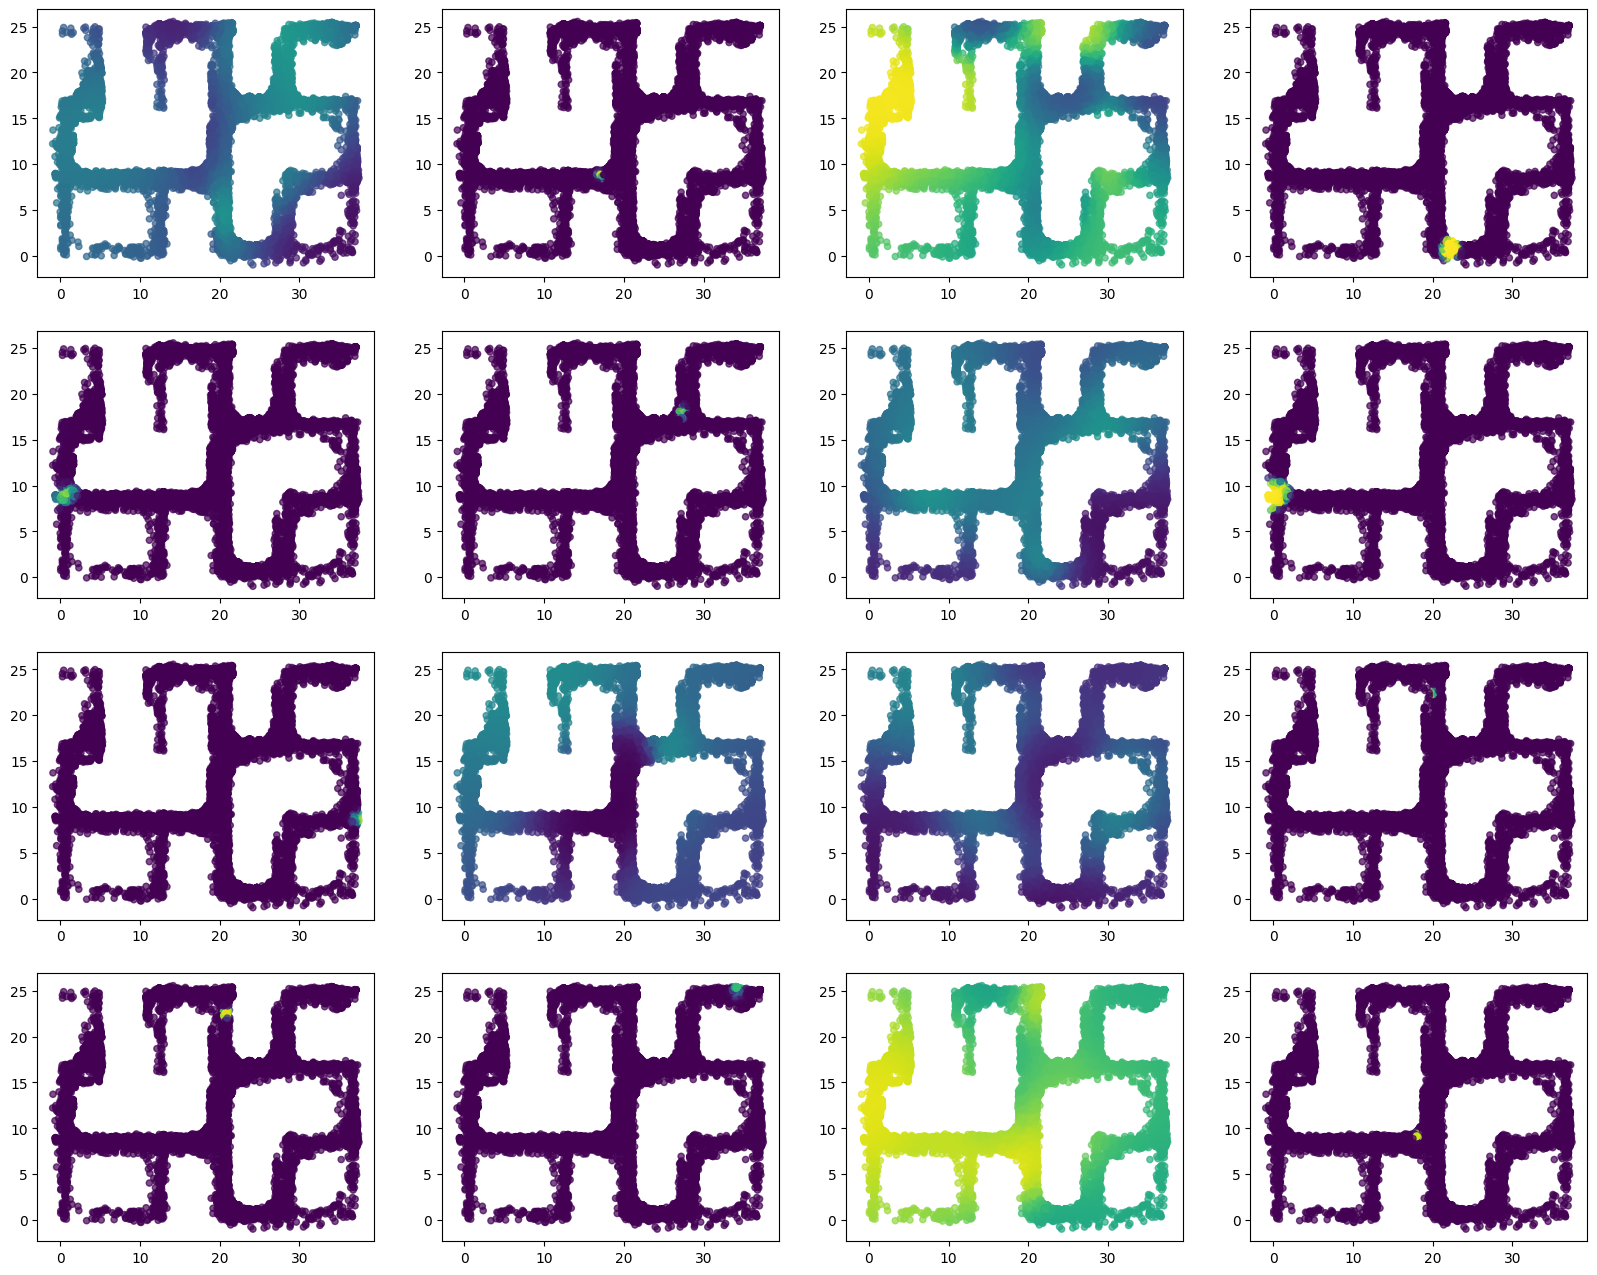

In [1016]:
eval_num_envs = 16
num_anchors = 16

mask = reward_generator.generate_boolean_mask(eval_num_envs, len(FEATURES_TO_CONSIDER), p=0.3)
mask = torch.zeros_like(mask)
mask[..., [0, 1,]] = 1.
# mask = None

with torch.no_grad():
    w, info = reward_generator.get_z_from_random_anchors(eval_num_envs, min_num_anchors=num_anchors, max_num_anchors=num_anchors, mask=mask)
    
fig, axs, info = visualize_rewards_and_trajectories(w, reward_generator, mask=mask)

# info['anchors_rewards'].flatten()

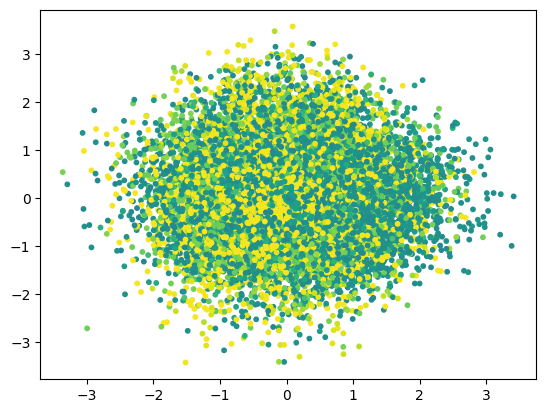

In [615]:
plt.scatter(info['state'][..., 15], info['state'][..., 16], c=info['r'], vmin=-1, vmax=1, s=10)

In [1018]:
# torch.save(rg_model.state_dict(), 'shared_models/offline_fre+reward_generator-rg_model.pth')

---

In [1019]:
def sample_reward_function_fre(batch_size, num_random_samples):

    trajectories_idx = torch.randint(0, num_trajectories, (batch_size*num_random_samples,))
    states_idx = torch.randint(0, len_trajectory, (batch_size*num_random_samples,))
    random_states = dataset_trajectories[trajectories_idx, states_idx] # get the random states
    random_states = random_states.reshape(batch_size, num_random_samples, len(FEATURES_TO_CONSIDER)).to(device)

    reward_params = torch.zeros((batch_size, 128))
    random_states_rewards = torch.zeros((batch_size, num_random_samples))


    # num_anchors = 16
    mask = reward_generator.generate_boolean_mask(batch_size, len(FEATURES_TO_CONSIDER), p=0.3)
    mask = torch.zeros_like(mask)
    mask[..., [0, 1]] = 1
    

    with torch.no_grad():
        reward_params, _ = reward_generator.get_z_from_random_anchors(batch_size, min_num_anchors=MIN_NUM_ANCHORS, max_num_anchors=MAX_NUM_ANCHORS, mask=mask)
        
        x = random_states * mask.unsqueeze(1).repeat(1, num_random_samples, 1).to(device)
        
        random_states_rewards = reward_generator.get_reward(
            x.reshape(-1, obs_dim), 
            reward_params.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        ).reshape(batch_size, num_random_samples)
    
    return reward_params, random_states, random_states_rewards

In [1020]:
def get_reward(reward_params, random_states):
    """
    reward_params: (batch_size, z_dim)
    random_states: (batch_size, num_states, obs_dim)
    """

    assert len(reward_params.shape) == 2
    assert len(random_states.shape) == 3
    assert reward_params.shape[0] == random_states.shape[0]
    
    batch_size, num_random_samples, _ = random_states.shape
    
    with torch.no_grad():
        rewards = reward_generator.get_reward(
            random_states.reshape(-1, obs_dim), 
            reward_params.unsqueeze(1).repeat(1, num_random_samples, 1).reshape(-1, 128)
        ).reshape(batch_size, num_random_samples)
    
    return rewards

In [1021]:
# reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=16, num_random_samples=200)

# get_reward(reward_params, random_states)

In [1022]:
# reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=16, num_random_samples=200)

# for b in range(16):
#     # plt.scatter(dataset_trajectories[:, ::10, 0], dataset_trajectories[:, ::10, 1])
#     plt.scatter(random_states[b, :, 0].cpu(), random_states[b, :, 1].cpu(), c=random_states_rewards[b], vmin=-1, vmax=1)
#     plt.show()

In [1023]:
fre_network = FRENetwork(obs_len=obs_dim).to(device)
# fre_network.load_state_dict(torch.load('shared_models/offline_fre-fre_network.pth'))
optimimizer = torch.optim.Adam(fre_network.parameters(), lr=0.001)

reward_losses = []
kl_losses = []

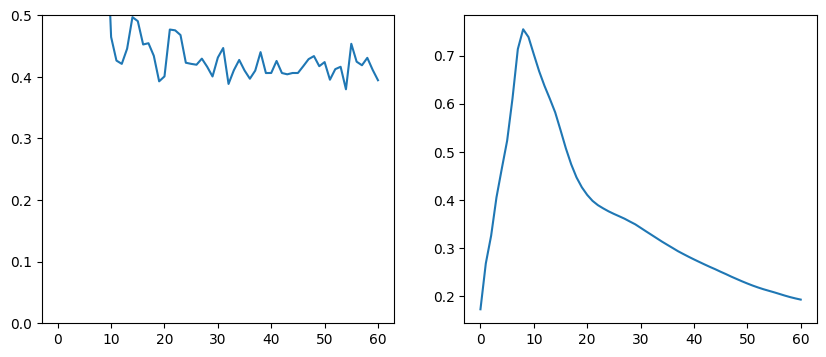

  1%|          | 69/10000 [00:10<25:09,  6.58it/s]


KeyboardInterrupt: 

In [1024]:
num_encode_states = 128
num_decode_states = 128

for i in tqdm(range(10_000)):
    
    reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=256, num_random_samples=(num_encode_states+num_decode_states))
    
    encode_obs = random_states[:, :num_encode_states, :].to(device)
    decode_obs = random_states[:, num_encode_states:, :].to(device)
    
    encode_rewards = random_states_rewards[:, :num_encode_states, None].to(device)
    decode_rewards = random_states_rewards[:, num_encode_states:, None].to(device)

            
    # encode_rewards, goals = goal_rewards(encode_obs, goals=None)
    # decode_rewards, goals = goal_rewards(decode_obs, goals=goals)
    
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    w_mean, w_log_std = fre_network.get_transformer_encoding(reward_state_pairs)
    
    
    # Calculate the loss:
    
    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    rewards_pred = fre_network.get_reward_pred(w, decode_obs)
    
    reward_pred_loss = ((rewards_pred - decode_rewards)**2).mean()
    kl_loss = -0.5 * (1 + w_log_std - w_mean**2 - torch.exp(w_log_std)).mean()
    loss = reward_pred_loss + kl_loss * 0.01
    
    optimimizer.zero_grad()
    loss.backward()
    optimimizer.step()
    
    reward_losses.append(reward_pred_loss.item())
    kl_losses.append(kl_loss.item())
    
    if i % 20 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 2, figsize=(10, 4))
        axs[0].plot(reward_losses)
        # axs[0].set_xscale('log')
        axs[0].set_ylim(0, 0.5)
        axs[1].plot(kl_losses)
        plt.show()
        


In [21]:
# torch.save(fre_network.state_dict(), 'models/offline_fre-fre_network.pth')

In [953]:
from utils.antmaze_benchmark import VelocityRewardFunction, SimplexRewardFunction, TestRewPath, TestRewLoop, TestRewMatrixEdges, goal_reaching_reward

velocity_reward_function = VelocityRewardFunction()
simplex_reward_function = SimplexRewardFunction(num_simplex=10)

benchmarks = [
    (goal_reaching_reward, 'goal_bottom', np.array([28, 0])),
    (goal_reaching_reward, 'goal_left', np.array([0, 15])),
    (goal_reaching_reward, 'goal_top', np.array([35, 24])),
    (goal_reaching_reward, 'goal_center', np.array([12, 24])), 
    (goal_reaching_reward, 'goal_right', np.array([33, 16])),
    (velocity_reward_function.compute_reward, 'vel_left', [-1, 0]),
    (velocity_reward_function.compute_reward, 'vel_up', [0, 1]),
    (velocity_reward_function.compute_reward, 'vel_down', [0, -1]),
    (velocity_reward_function.compute_reward, 'vel_right', [1, 0]),
    (simplex_reward_function.compute_reward, 'simplex_1', 1),
    (simplex_reward_function.compute_reward, 'simplex_2', 2),
    (simplex_reward_function.compute_reward, 'simplex_3', 3),
    (simplex_reward_function.compute_reward, 'simplex_4', 4),
    (simplex_reward_function.compute_reward, 'simplex_5', 5),
    (TestRewPath().compute_reward, 'path_center', None),
    (TestRewLoop().compute_reward, 'path_loop', None),
    (TestRewMatrixEdges().compute_reward, 'path_edges', None)
]

Generating simplex seeds


100%|██████████| 10/10 [00:00<00:00, 70.40it/s]


In [980]:
num_eval_states = 10_000

reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=(128+num_eval_states))

encode_obs = random_states[:, :128, :].to(device)
decode_obs = random_states[:, 128:, :].to(device)

encode_rewards = random_states_rewards[:, :128, None].to(device)
decode_rewards = random_states_rewards[:, 128:, None].to(device)

# benchmark_id = 1
# encode_rewards = benchmarks[benchmark_id][0](encode_obs.cpu(), np.array([0, 15])).unsqueeze(-1).to(device)
# decode_rewards = benchmarks[benchmark_id][0](decode_obs.cpu(), np.array([0, 15])).unsqueeze(-1).to(device)

        
# encode_rewards, goals = goal_rewards(encode_obs, goals=None)
# decode_rewards, goals = goal_rewards(decode_obs, goals=goals)

reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)

with torch.no_grad():
    w_mean, w_log_std = fre_network.get_transformer_encoding(reward_state_pairs)

    # Calculate the loss:

    w = w_mean + torch.normal(0, 1, size=w_mean.shape, device=device) * torch.exp(w_log_std)
    # w = w_mean
    
    rewards_pred = fre_network.get_reward_pred(w, decode_obs)

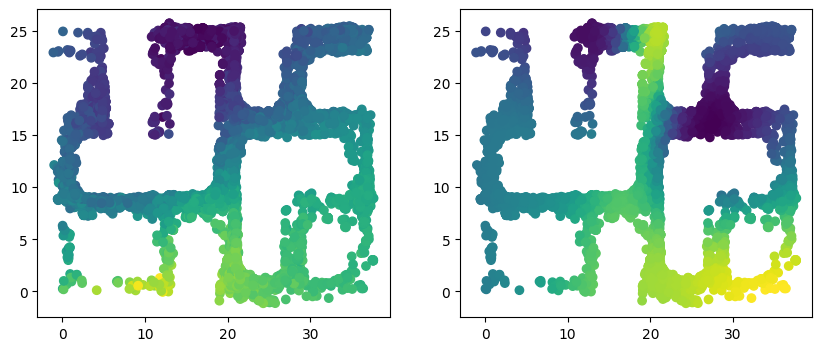

In [981]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(decode_obs[..., 0].cpu(), decode_obs[..., 1].cpu(), c=rewards_pred.cpu())
axs[1].scatter(decode_obs[..., 0].cpu(), decode_obs[..., 1].cpu(), c=decode_rewards.cpu())

# IQL:

In [982]:
import torch
import torch.nn as nn

class MLP(nn.Module):
    """Generic MLP with Mish activation and LayerNorm."""
    def __init__(self, input_dim, hidden_dims, output_dim):
        super().__init__()
        layers = []
        prev_dim = input_dim

        # Add hidden layers with Mish activation and LayerNorm
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.Mish())
            # layers.append(nn.LayerNorm(hidden_dim))
            prev_dim = hidden_dim  # Update input size for next layer
        
        # Final output layer
        layers.append(nn.Linear(prev_dim, output_dim))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)


class ValueCritic(nn.Module):
    def __init__(self, obs_dim, hidden_dims):
        super().__init__()
        self.model = MLP(obs_dim, hidden_dims, output_dim=1)

    def forward(self, x):
        return self.model(x)


class Critic(nn.Module):
    def __init__(self, obs_dim, action_dim, hidden_dims):
        super().__init__()

        self.model1 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)
        self.model2 = MLP(obs_dim + action_dim, hidden_dims, output_dim=1)

    def forward(self, x, action):
        x = torch.cat((x, action), dim=-1)
        
        q1 = self.model1(x)
        q2 = self.model2(x)
        
        return q1, q2



class Actor(nn.Module):
    def __init__(self, input_dim, action_dim, hidden_dims, init_std=0.0):
        super().__init__()
        self.model = MLP(input_dim, hidden_dims, output_dim=action_dim)  # MLP only predicts mean
        
        # Learnable log standard deviation (initialized to `init_std`)
        self.log_std = nn.Parameter(torch.ones(action_dim) * init_std)

    def forward(self, x, temperature=1.0):
        mean = self.model(x)  # Predict action mean

        log_std = torch.clip(self.log_std, -20, 2)
        mean = torch.clip(mean, -5, 5)

        return torch.distributions.Normal(
            mean, 
            torch.exp(log_std)*temperature
        )


from torch.optim.lr_scheduler import CosineAnnealingLR
import copy


class IQL(nn.Module):
    def __init__(self, state_dim, action_dim, w_dim=128):
        super(IQL, self).__init__()
        self.obs_len = state_dim
                
        self.critic = Critic(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        self.target_critic = copy.deepcopy(self.critic)
        for param in self.target_critic.parameters():
            param.requires_grad = False
        
        self.value = ValueCritic(w_dim + state_dim, hidden_dims=[256, 256])        
        self.actor = Actor(w_dim + state_dim, action_dim, hidden_dims=[256, 256])
        
        self.critic_optim = torch.optim.Adam(self.critic.parameters(), lr=0.003)
        self.value_optim = torch.optim.Adam(self.value.parameters(), lr=0.003)
        self.actor_optim = torch.optim.Adam(self.actor.parameters(), lr=0.003)
        self.actor_lr_schedule = CosineAnnealingLR(self.actor_optim, 100000)
        
        
    def get_value(self, w, obs):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.value(w_and_obs)

    def get_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.critic(w_and_obs, actions)
    
    def get_target_critic(self, w, obs, actions):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.target_critic(w_and_obs, actions)

    def get_actor(self, w, obs, temperature=1.0):
        w_and_obs = torch.concatenate([w, obs], dim=-1)
        return self.actor(w_and_obs, temperature)
    
    
    
# def update_target_critic(critic, target_critic, tau):

#     critic_state_dict = critic.state_dict()
#     target_critic_state_dict = target_critic.state_dict()

#     for key in critic_state_dict:
#         target_critic_state_dict[key] = tau * critic_state_dict[key] + (1 - tau) * target_critic_state_dict[key]

#     target_critic.load_state_dict(target_critic_state_dict)
    
    
def update_target_critic(source, target, alpha):
    for target_param, source_param in zip(target.parameters(), source.parameters()):
        target_param.data.mul_(1. - alpha).add_(source_param.data, alpha=alpha)
    
    
def expectile_loss(u, expectile=0.7):
    weight = torch.where(
        u.detach() >= 0, 
        torch.tensor(expectile, dtype=u.dtype), 
        torch.tensor(1 - expectile, dtype=u.dtype)
    )
    return weight * (u ** 2)


def smooth_and_downsample(losses, smoothing=0.9, max_points=100):
    if not losses: return []
    smoothed = [losses[0]]
    for loss in losses[1:]:
        smoothed.append(smoothing * smoothed[-1] + (1 - smoothing) * loss)
    downsample = max(1, len(smoothed) // max_points)  # Ensure at least 1
    return smoothed[::downsample]

In [983]:
def get_iql_training_data(batch_size, num_states):

    trajectory_idx = torch.randint(0, num_trajectories, (batch_size*num_states,))
    state_idx = torch.randint(0, len_trajectory, (batch_size*num_states,)) % 1000

    states = dataset_trajectories[trajectory_idx, state_idx].reshape(batch_size, num_states, obs_dim)
    next_states = dataset_trajectories[trajectory_idx, state_idx+1].reshape(batch_size, num_states, obs_dim)
    actions = dataset_actions[trajectory_idx, state_idx].reshape(batch_size, num_states, 8)
    masks = ~dataset_timeouts[trajectory_idx, state_idx+1].reshape(batch_size, num_states, 1)
    
    return {
        'states': states.to(device),
        'actions': actions.to(device),
        'next_states': next_states.to(device),
        'masks': masks.to(device),
        'trajectory_idx': trajectory_idx.reshape(batch_size, num_states),
        'state_idx': state_idx.reshape(batch_size, num_states)
    }

In [984]:
iql_agent = IQL(state_dim=obs_dim, action_dim=8).to(device)
# iql_agent.load_state_dict(torch.load('shared_models/iql_agent.pth'))

actor_losses = []
v_losses, q_losses = [], []
mse_errors = []
stds = []

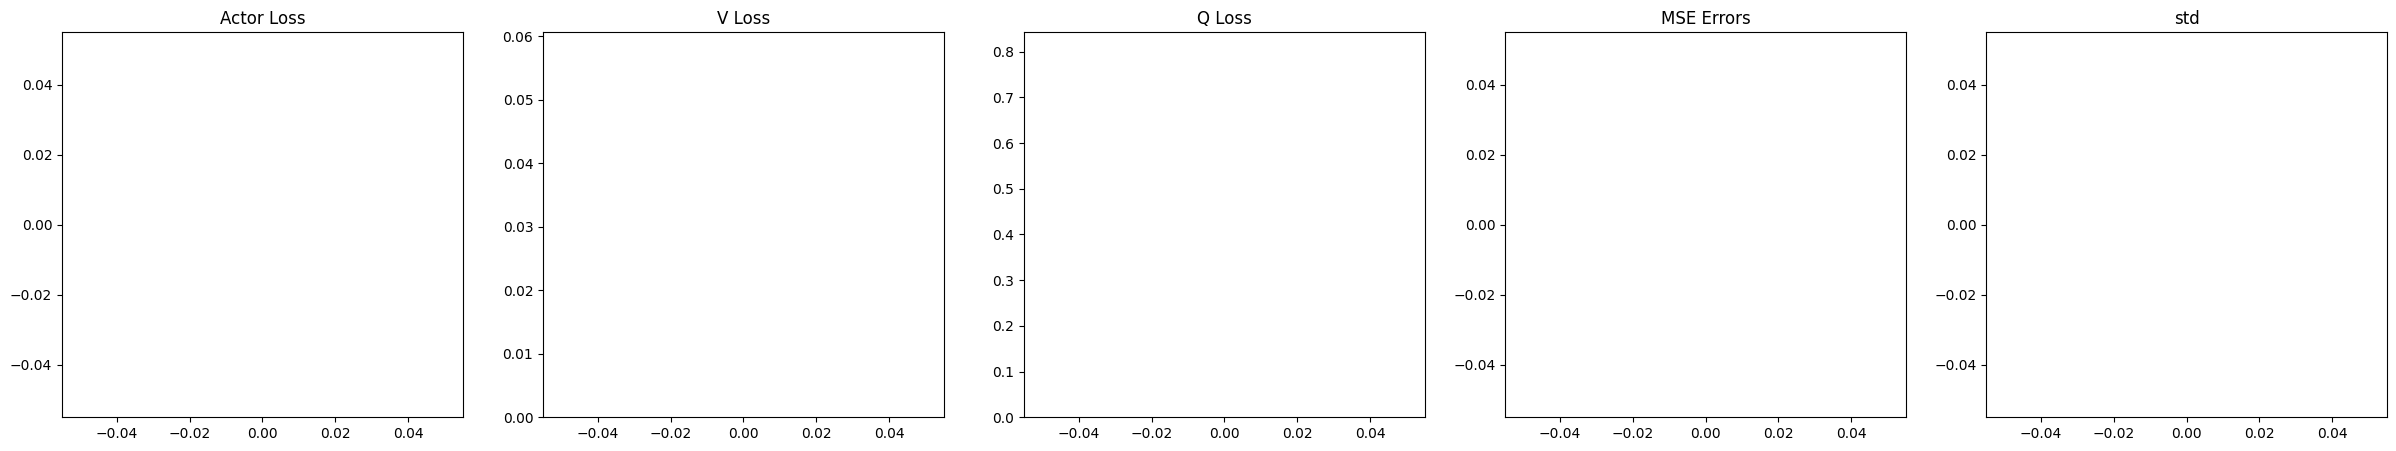

  4%|▎         | 36/1000 [00:03<01:22, 11.65it/s]


KeyboardInterrupt: 

In [985]:
config = {
    'expectile': 0.8,
    'temperature': 3.0,
    'discount': 0.99,
    'tau': 0.005,
}

iql_batch_size = 64
iql_num_states = 512



for timestep in tqdm(range(1000)):

    
    reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=iql_batch_size, num_random_samples=128)
    encode_obs = random_states[:, :128, :].to(device)
    encode_rewards = random_states_rewards[:, :128, None].to(device)
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    
    batch = get_iql_training_data(
        batch_size=iql_batch_size, 
        num_states=iql_num_states,
    )
    
    # break
    
    
    with torch.no_grad():
        w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)
        batch['rewards'] = get_reward(reward_params=reward_params, random_states=batch['states']).unsqueeze(-1)

    # break

    # Implicit Q-Learning
    w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)
    
    with torch.no_grad():
        
        target_q1, target_q2 = iql_agent.get_target_critic(w_target, batch['states'], batch['actions'])
        target_q1, target_q2 = target_q1.detach(), target_q2.detach()
        target_q = torch.minimum(target_q1, target_q2)
        next_v = iql_agent.get_value(w_target, batch['next_states']).detach()
    
    
    # Value Loss: Update V towards expectile of min(q1, q2).
    
    v = iql_agent.get_value(w_target, batch['states'])
    v_loss = expectile_loss(target_q - v, config['expectile'])
        
    
    v_loss = v_loss.mean()

    iql_agent.value.zero_grad(set_to_none=True)
    v_loss.backward()
    iql_agent.value_optim.step()

    # Critic Loss. Update Q = r #############################
    
    targets = batch['rewards'] + config['discount'] * batch['masks'] * next_v
    

    q1, q2 = iql_agent.get_critic(w_target, batch['states'], batch['actions'])
    q_loss = ((q1 - targets).pow(2).mean() + (q2 - targets).pow(2).mean()) / 2
    q_loss = q_loss
    
    iql_agent.critic.zero_grad(set_to_none=True)
    q_loss.backward()
    iql_agent.critic_optim.step()


    update_target_critic(iql_agent.critic, iql_agent.target_critic, config['tau'])


    value_info = {
        'v_loss': v_loss,
        'q_loss': q_loss,
        'v': v.mean(),
        'q': torch.minimum(q1, q2).mean(),
    }


    ########################################################################################
    
    
    
    v_losses.append(v_loss.item())
    q_losses.append(q_loss.item())
    
    if timestep % 50 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 5, figsize=(30, 5))
        
        axs[0].plot(smooth_and_downsample(actor_losses))
        # axs[0].set_ylim(0,max(actor_losses[-100:]))
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(smooth_and_downsample(mse_errors))
        # axs[3].set_ylim(0,max(mse_errors[-100:]))
        axs[3].set_title("MSE Errors")
        
        axs[4].plot(smooth_and_downsample(stds))
        axs[4].set_title("std")

        plt.show()
        
    # break

In [986]:
iql_agent.actor = Actor(128 + 29, 8, hidden_dims=[256, 256]).to(device)        
iql_agent.actor_optim = torch.optim.Adam(iql_agent.actor.parameters(), lr=0.003)
iql_agent.actor_lr_schedule = CosineAnnealingLR(iql_agent.actor_optim, 5000)

actor_losses = []
mse_errors = []
stds = []

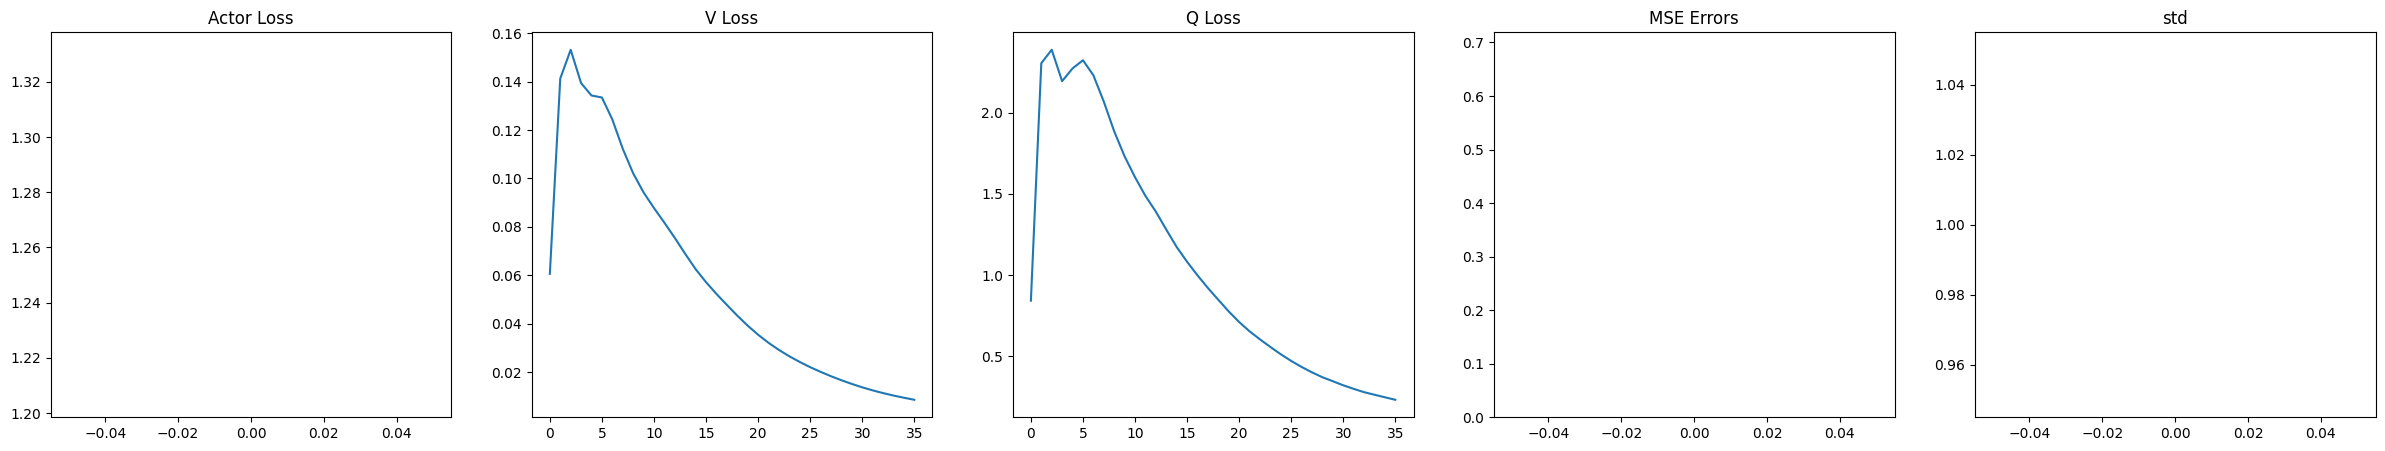

  1%|          | 46/5000 [00:02<04:00, 20.62it/s]


KeyboardInterrupt: 

In [987]:
for timestep in tqdm(range(5000)):

    
    reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=iql_batch_size, num_random_samples=128)
    encode_obs = random_states[:, :128, :].to(device)
    encode_rewards = random_states_rewards[:, :128, None].to(device)
    reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
    
    batch = get_iql_training_data(
        batch_size=iql_batch_size, 
        num_states=iql_num_states,
    )
    
    # break
    
    
    with torch.no_grad():
        w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)

    # break

    # Implicit Q-Learning
    w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)
    
    with torch.no_grad():
        
        target_q1, target_q2 = iql_agent.get_target_critic(w_target, batch['states'], batch['actions'])
        target_q1, target_q2 = target_q1.detach(), target_q2.detach()
        target_q = torch.minimum(target_q1, target_q2)
        v = iql_agent.get_value(w_target, batch['states'])
    

    # Actor Loss ############################################

    adv = (target_q - v).detach()
    actions = batch['actions']
    exp_a = torch.exp(adv.detach() * 3).clamp(max=100)
    
    dist = iql_agent.get_actor(w_target, batch['states'])
    log_probs = dist.log_prob(actions)
    actor_loss = -(exp_a * log_probs).mean()
    
    iql_agent.actor.zero_grad(set_to_none=True)
    actor_loss.backward()
    iql_agent.actor_optim.step()
    iql_agent.actor_lr_schedule.step()
    
    
    std = dist.stddev.mean()
    mse_error = ((dist.loc - batch['actions'])**2).mean()
    
    actor_info = {
        'actor_loss': actor_loss,
        'std': std,
        'adv': adv.mean(),
        'mse_error': mse_error,
    }

    ########################################################################################
    
    
    actor_losses.append(actor_loss.item())
    mse_errors.append(mse_error.item())
    stds.append(std.item())
    
    if timestep % 100 == 0:
        clear_output(True)
        fig, axs = plt.subplots(1, 5, figsize=(30, 5))
        
        axs[0].plot(smooth_and_downsample(actor_losses))
        # axs[0].set_ylim(0,max(actor_losses[-100:]))
        axs[0].set_title("Actor Loss")
        
        axs[1].plot(smooth_and_downsample(v_losses))
        # axs[1].set_ylim(0,max(v_losses[-100:]))
        axs[1].set_title("V Loss")
        
        axs[2].plot(smooth_and_downsample(q_losses))
        # axs[2].set_ylim(0,max(q_losses[-100:]))
        axs[2].set_title("Q Loss")
        
        axs[3].plot(smooth_and_downsample(mse_errors))
        axs[3].set_ylim(0,max(mse_errors[-100:]))
        axs[3].set_title("MSE Errors")
        
        axs[4].plot(smooth_and_downsample(stds))
        axs[4].set_title("std")

        plt.show()
        
    # break

In [ ]:
# plt.hist(exp_a.cpu().flatten())

In [866]:
reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=128)
encode_obs = random_states[:, :128, :].to(device)
encode_rewards = random_states_rewards[:, :128, None].to(device)
reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)
    
batch = get_iql_training_data(
    batch_size=1, 
    num_states=2000,
)

with torch.no_grad():
    w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)

# break

# Implicit Q-Learning
w_target = w_mean.unsqueeze(1).repeat(1, batch['states'].shape[1], 1)

with torch.no_grad():
    
    target_q1, target_q2 = iql_agent.get_target_critic(w_target, batch['states'], batch['actions'])
    target_q1, target_q2 = target_q1.detach(), target_q2.detach()
    target_q = torch.minimum(target_q1, target_q2)
    v = iql_agent.get_value(w_target, batch['states'])

exp_a = torch.exp(target_q - v).clamp(max=2)
# exp_a = target_q - v

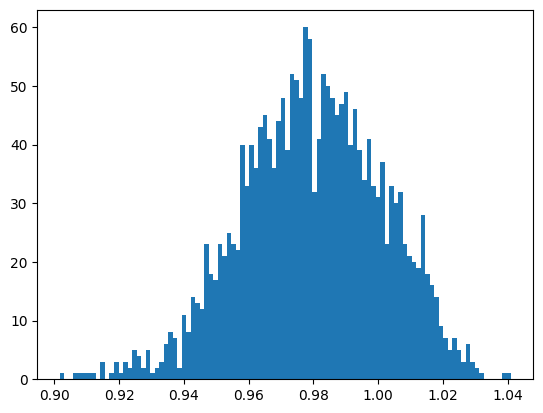

In [867]:
_ = plt.hist(exp_a.cpu().flatten(), bins=100)

In [872]:
# fig, axs = plt.subplots(1, 3, figsize=(15, 4))
# _ = axs[0].scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu(), c=v.detach().flatten().cpu(), s=10, alpha=1)
# _ = axs[1].scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu(), c=exp_a.detach().flatten().cpu(), s=10, alpha=1)

# add_largest_maze_walls(axs[0])
# add_largest_maze_walls(axs[1])

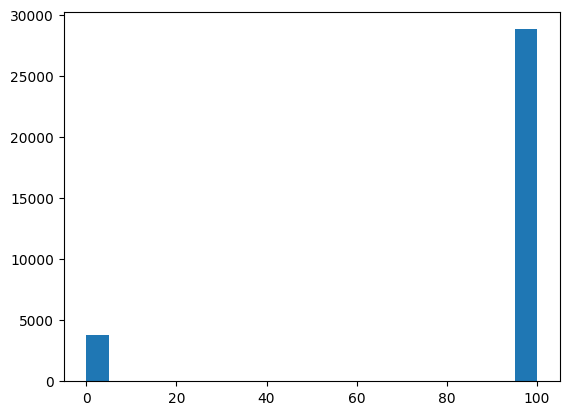

In [ ]:
_ = plt.hist(exp_a.flatten().cpu(), bins=20)

---

---

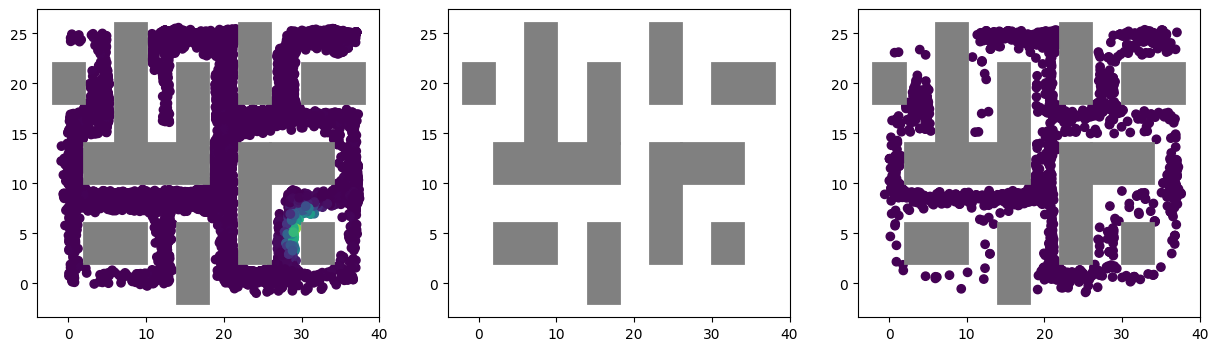

In [49]:
b = 0
eval_states, eval_rewards = get_eval_rewards(w_mean[[b]])

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].scatter(eval_states[..., 0], eval_states[..., 1], c=eval_rewards, vmin=-1, vmax=1)
add_largest_maze_walls(axs[0])


x = batch['states'][b][batch['alpha'][b].bool().squeeze(-1) == 1].cpu()
c = batch['G_s'][b][batch['alpha'][b].bool().squeeze(-1) == 1].cpu()
axs[1].scatter(x[:, 0], x[:, 1], c=c.cpu())
add_largest_maze_walls(axs[1])

x = batch['states'][b][batch['alpha'][b].bool().squeeze(-1) == 0].cpu()
c = batch['G_s'][b][batch['alpha'][b].bool().squeeze(-1) == 0].cpu()
axs[2].scatter(x[:, 0], x[:, 1], c=c.cpu())
add_largest_maze_walls(axs[2])

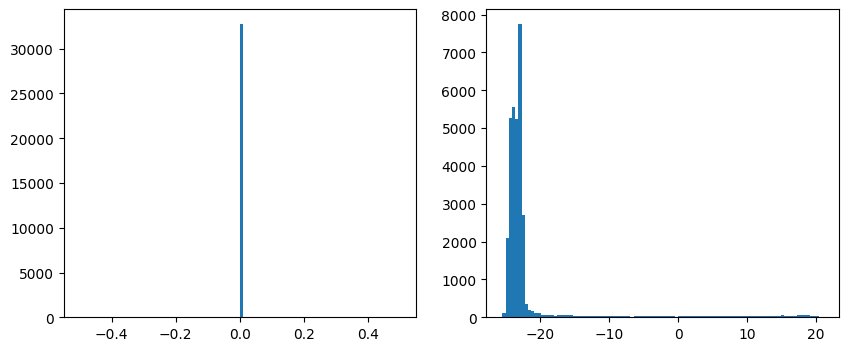

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
cond = batch['G_s'] == 0
_ = axs[0].hist(batch['G_s'][cond].flatten().cpu().detach(), bins=100)
_ = axs[1].hist(v[cond].flatten().cpu().detach(), bins=100)

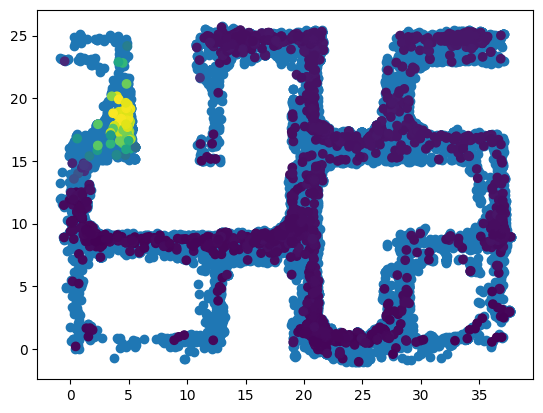

In [ ]:
plt.scatter(batch['states'][..., 0].cpu(), batch['states'][..., 1].cpu())
plt.scatter(batch['states'][b, :, 0].cpu(), batch['states'][b, :, 1].cpu(), c=v[b].detach().flatten().cpu())

---

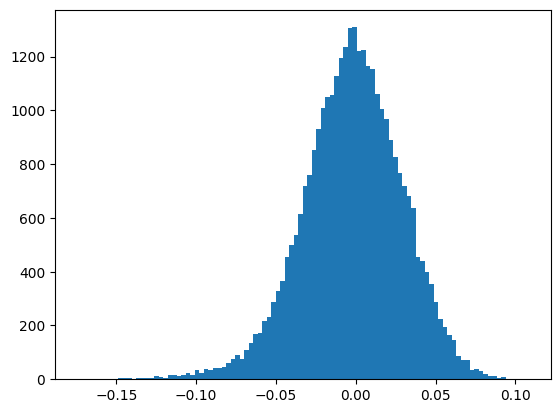

In [874]:
_ = plt.hist(adv.clip(-2, 2).flatten().cpu(), bins=100)

# Benchmark:

In [909]:
import matplotlib.patches as patches


def add_largest_maze_walls(ax):    

    maze_optim = [
        (1, 1, 1, 2),    
        (0, 4, 2, 1),
        (3, 1, 1, 4),
        (5, 0, 1, 1),
        (4, 2, 3, 1),
        (1, 6, 3, 1),
        (4, 4, 2, 1),
        (5, 6, 2, 1),
        (1, 8, 1, 1),
        (3, 7, 1, 2),
        (5, 8, 1, 2)
    ]

    block_size = 0.025 * 80

    height, width = 7, 10
    torso_x, torso_y = (width - 1)*block_size, (height - 1)*block_size

    rects = []
    for i in range(len(maze_optim)):
        (y, x, w, h) = maze_optim[i]
            
        x = x * block_size * 2 - torso_x + (h - 1) * block_size - h * block_size + 18
        y = y * block_size * 2 - torso_y + (w - 1) * block_size - w * block_size + 12
        h, w = h * block_size * 2, w * block_size * 2
        w = w * 1.
        y = y * 1.
        rect = patches.Rectangle((x, y), h, w, linewidth=2, edgecolor='gray', facecolor='gray')

        ax.add_patch(rect)
        
        
        
def get_eval_rewards(eval_z, to_keep:list=None): 
    states = dataset_trajectories[0:300, :1000:10].reshape(-1, obs_dim)
    states = states.to(device)

    res = []
    for i in range(len(eval_z)):
        
        zi = eval_z[i].unsqueeze(0)
        with torch.no_grad():
            x = states.unsqueeze(0)
            if to_keep is not None:
                x = torch.zeros_like(x)
                x[..., to_keep] = states[..., to_keep]
            r = fre_network.get_reward_pred(zi, x).cpu()
            
            res.append(r)
    
    res = torch.stack(res).squeeze(-1)
    
    return x.cpu(), res.cpu()

In [913]:

def run_test(fre_network, iql_agent, benchmark_id, num_evals, num_eval_anchors):


    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]

    produced_trajectories = []
    for _ in range(num_evals):
        

        reward_params, random_states, random_states_rewards = sample_reward_function_fre(batch_size=1, num_random_samples=num_eval_anchors)
        encode_obs = random_states[:, :128, :].to(device)

        # encode_rewards = random_states_rewards[:, :128, None].to(device)
        # decode_rewards = random_states_rewards[:, 128:, None].to(device)

        encode_rewards = benchmark_reward_function(encode_obs.cpu(), benchmark_param).unsqueeze(-1).to(device)

        reward_state_pairs = torch.concatenate((encode_obs, encode_rewards), axis=-1)

        with torch.no_grad():
            w_mean, _ = fre_network.get_transformer_encoding(reward_state_pairs)  
            
            
            
        env.reset()
        location = (20, 15)
        start_state = reset_to_location(env, location)
        # start_state = normalize_dataset_coords(start_state)[..., :]
        state = start_state

        tensor_state = torch.tensor(state).reshape(1, -1).to(device).float() 
    
    
        produced_trajectory = []    

        for step in tqdm(range(10)):
            
            produced_trajectory.append(state)
            
            with torch.no_grad():
                tensor_state = torch.tensor(state).reshape(1, -1).to(device).float()
                dist = iql_agent.get_actor(w_mean, tensor_state)
                action = dist.loc.cpu()
                action = np.array(action[0]).clip(-1, 1)

                
            new_state, _, _, _ = env.step(action)
            
            # state = normalize_dataset_coords(new_state)[..., :]
            
        produced_trajectory = np.stack(produced_trajectory)
        produced_trajectories.append(produced_trajectory)
    
    produced_trajectories = np.stack(produced_trajectories)

    return produced_trajectories, w_mean



Target Goal:  (32.70976026586461, 24.576276452650625)


100%|██████████| 10/10 [00:00<00:00, 868.48it/s]


Target Goal:  (33.19450232077075, 25.146552600713417)


100%|██████████| 10/10 [00:00<00:00, 889.66it/s]


Target Goal:  (32.86759732386227, 25.166397262839535)


...

100%|██████████| 10/10 [00:00<00:00, 686.39it/s]


Target Goal:  (32.115388971860696, 24.562011098229714)


100%|██████████| 10/10 [00:00<00:00, 728.62it/s]


Target Goal:  (32.993348069230564, 25.330336182251934)


100%|██████████| 10/10 [00:00<00:00, 750.32it/s]


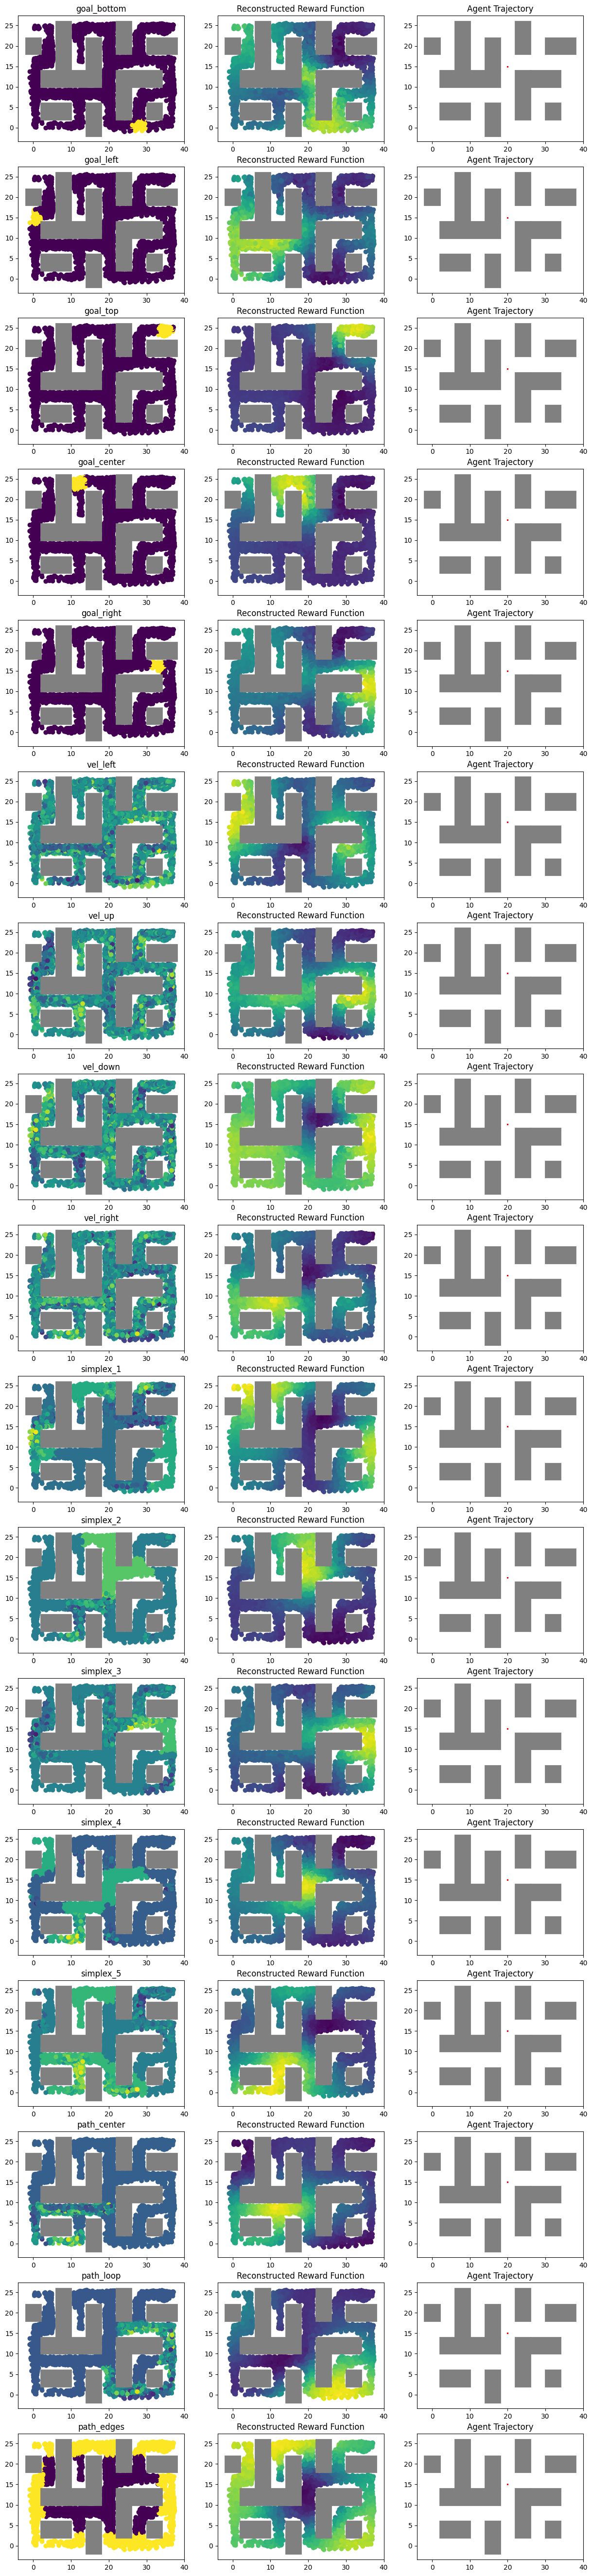

In [914]:
fig, axs = plt.subplots(len(benchmarks), 3, figsize=(15, len(benchmarks)*4))
# fig, axs = plt.subplots(5, 3, figsize=(15, 5*4))

all_produced_trajectories = []
for benchmark_id in range(len(benchmarks)):
# for benchmark_id in range(5):

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
    
    produced_trajectory, w_mean = run_test(fre_network, iql_agent, benchmark_id=benchmark_id, num_evals=1, num_eval_anchors=128)
    

    eval_states, eval_rewards = get_eval_rewards(w_mean)
    real_eval_rewards = benchmark_reward_function(eval_states, benchmark_param)

    axs[benchmark_id, 0].scatter(eval_states[..., 0], eval_states[..., 1], c=real_eval_rewards)
    axs[benchmark_id, 1].scatter(eval_states[..., 0], eval_states[..., 1], c=eval_rewards)
    axs[benchmark_id, 2].scatter(produced_trajectory[..., 0], produced_trajectory[..., 1], c='red', s=1)
    
    add_largest_maze_walls(axs[benchmark_id, 0])
    add_largest_maze_walls(axs[benchmark_id, 1])
    add_largest_maze_walls(axs[benchmark_id, 2])
    
    # plt.title(f'{benchmark_test_label}')
    axs[benchmark_id, 0].set_title(f'{benchmark_test_label}')
    axs[benchmark_id, 1].set_title(f'Reconstructed Reward Function')
    axs[benchmark_id, 2].set_title(f'Agent Trajectory')
    
    all_produced_trajectories.append(produced_trajectory)
    
all_produced_trajectories = np.stack(all_produced_trajectories)

plt.show()

In [ ]:
trajectory_rewards

tensor([1646., 1132., 1364.])

tensor([0, 0, 0])

In [ ]:
for benchmark_id in range(len(benchmarks)):

    benchmark_reward_function, benchmark_test_label, benchmark_param = benchmarks[benchmark_id]
    

    trajectory_states = torch.tensor(all_produced_trajectories[benchmark_id]).reshape(1, -1, 29)
    trajectory_states_rewards = benchmark_reward_function(trajectory_states, benchmark_param).float()
    trajectory_states_rewards = trajectory_states_rewards.reshape(
        all_produced_trajectories.shape[1],
        all_produced_trajectories.shape[2],
    )
    trajectory_rewards = trajectory_states_rewards.sum(dim=-1)
    
    if 'goal' in benchmark_test_label: 
        trajectory_rewards = torch.where(trajectory_rewards != -2000, 1., 0.)
        
    print(benchmark_test_label, ':')
    print('\tRewards:', trajectory_rewards.tolist())
    print('\tmean:', trajectory_rewards.mean().item())
    print('\tstd:', trajectory_rewards.std().item())
    
    # break

goal_bottom :
	Rewards: [0.0, 0.0, 0.0, 0.0, 1.0]
	mean: 0.20000000298023224
	std: 0.4472135901451111
goal_left :
	Rewards: [0.0, 0.0, 0.0, 0.0, 0.0]
	mean: 0.0
	std: 0.0
goal_top :
	Rewards: [0.0, 0.0, 0.0, 0.0, 0.0]
	mean: 0.0
	std: 0.0
goal_center :
	Rewards: [0.0, 0.0, 0.0, 0.0, 1.0]
	mean: 0.20000000298023224
	std: 0.4472135901451111
goal_right :
	Rewards: [1.0, 0.0, 0.0, 0.0, 0.0]
	mean: 0.20000000298023224
	std: 0.4472135901451111


IndexError: index 5 is out of bounds for axis 0 with size 5

In [ ]:
all_produced_trajectories[benchmark_id].shape

(2, 10, 29)

4 tensor([-10., -10.]) tensor(-10.) tensor(0.)


In [ ]:
trajectory_rewards

tensor([-10, -10])